<a href="https://colab.research.google.com/github/vaneeshagupta/ds3001-sp25-project/blob/main/DS3001_01_Project_Wrangling_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data

The dataset consists of two primary sources of real estate market information: the Zillow Home Value Index (ZHVI) and home sales count data. The ZHVI dataset provides a time-series representation of median home values across various metropolitan areas in the United States, with values recorded on a monthly basis. The home sales dataset tracks the number of properties sold in these same metro areas over the same period. Each dataset contains identifiers such as RegionID, RegionName, and StateName, which allow for accurate merging and comparison of trends across regions. The data spans from at least 2008 onward, allowing for historical analysis of home prices and sales activity.

The overall research question we are investigating is how have home values and sales activity evolved over time in major U.S. metro areas, and what factors might be influencing these trends. This data is valuable for understanding long-term trends in the U.S. housing market, particularly in major metro areas. By analyzing ZHVI trends, we can observe how home values have changed over time, identify periods of rapid appreciation or depreciation, and assess the overall affordability of housing in different cities. Meanwhile, the home sales data helps us gauge market activity by showing fluctuations in transaction volume, which can reflect changes in supply and demand dynamics, economic conditions, and consumer confidence. Combining these datasets enables a deeper investigation into how sales activity correlates with price trends—whether rising prices lead to fewer transactions or if market booms encourage more sales. Furthermore, analyzing these patterns across multiple regions helps identify differences in regional housing market behavior, such as the resilience of certain cities during economic downturns or their susceptibility to housing bubbles.

One of the main challenges we faced with the ZHVI and home sales count data was ensuring that the data was complete and accurate. Since the dataset spans over a decade, any missing values could affect our analysis and lead to misleading conclusions. Merging both datasets was also tricky because differences in naming conventions and missing identifiers required careful data cleaning and alignment to make sure the data was consistent and usable. Another challenge was accounting for external factors that impact home values and sales, such as interest rates, economic conditions, and housing policies. Since these factors aren't directly included in the datasets, it was difficult to determine whether trends were driven by actual market changes or outside influences.



In [ ]:
# Starting by cleaning the data, creating dataframe, and handling missing values

import pandas as pd

zhvi_file = "/content/Metro_mean.csv"
sales_file = "/content/Metro_sales.csv"

# Load datasets
df_market = pd.read_csv(zhvi_file)
df_sales = pd.read_csv(sales_file)

# Drop rows with missing 'StateName'
df_market_clean = df_market.dropna(subset=['StateName'])
df_sales_clean = df_sales.dropna(subset=['StateName'])

# Convert 'RegionID' to string for merging
df_market_clean['RegionID'] = df_market_clean['RegionID'].astype(str)
df_sales_clean['RegionID'] = df_sales_clean['RegionID'].astype(str)

# Get relevant date columns (2008 onward)
date_columns_market = df_market_clean.columns[5:]
date_columns_sales = df_sales_clean.columns[5:]
common_dates = list(set(date_columns_market).intersection(set(date_columns_sales)))

# Keep only the relevant columns
df_market_clean = df_market_clean[['RegionID', 'RegionName', 'StateName'] + common_dates]
df_sales_clean = df_sales_clean[['RegionID', 'RegionName', 'StateName'] + common_dates]

# Merge datasets on 'RegionID', 'RegionName', and 'StateName'
df_merged = pd.merge(df_market_clean, df_sales_clean, on=['RegionID', 'RegionName', 'StateName'], suffixes=('_zhvi', '_sales'))

# Display the first few rows of the cleaned dataset
df_merged.head()


<ipython-input-11-e18018430256>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_market_clean['RegionID'] = df_market_clean['RegionID'].astype(str)
<ipython-input-11-e18018430256>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sales_clean['RegionID'] = df_sales_clean['RegionID'].astype(str)


,RegionID,RegionName,StateName,2012-09-30_zhvi,2014-05-31_zhvi,2008-12-31_zhvi,2021-02-28_zhvi,2021-08-31_zhvi,2009-02-28_zhvi,2017-04-30_zhvi,...,2012-06-30_sales,2023-09-30_sales,2011-08-31_sales,2020-08-31_sales,2020-02-29_sales,2015-03-31_sales,2024-12-31_sales,2016-06-30_sales,2020-12-31_sales,2009-04-30_sales
0,394913,"New York, NY",NY,365311.054617,390909.236487,417231.559267,536511.533534,569376.528251,410506.703286,437663.985297,...,12422.0,12961.0,11567.0,18176.0,11994.0,11455.0,12316.0,18563.0,22592.0,7227.0
1,753899,"Los Angeles, CA",CA,386979.566958,489577.064402,437871.356196,762042.828421,817977.587619,424605.939498,583316.615637,...,10886.0,5760.0,9087.0,10169.0,6965.0,9425.0,5914.0,11289.0,10991.0,8144.0
2,394463,"Chicago, IL",IL,168202.060483,190752.037827,227148.433157,260812.014648,278838.431291,220320.401217,219515.948673,...,10232.0,8737.0,8368.0,15503.0,7607.0,10395.0,7453.0,17438.0,14152.0,5243.0
3,394514,"Dallas, TX",TX,144676.212331,164294.652089,147737.819010,281806.695816,312906.243198,147188.990549,220770.739907,...,6794.0,5623.0,5721.0,9679.0,5972.0,6673.0,5395.0,9178.0,8196.0,4656.0
4,394692,"Houston, TX",TX,143268.438111,165114.425239,150642.372945,243475.756965,265229.851090,149399.074322,202507.249089,...,5440.0,NaN,4669.0,8241.0,5252.0,5946.0,4790.0,7741.0,8392.0,3812.0


In [ ]:
# Summary statistics for home values (ZHVI)
market_stats = df_merged.iloc[:, 3:].describe().transpose()
print("Home Value (ZHVI) Statistics:")
print(market_stats.head())

# Summary statistics for home sales
sales_stats = df_merged.iloc[:, len(common_dates) + 3:].describe().transpose()
print("\nHome Sales Statistics:")
print(sales_stats.head())

Home Value (ZHVI) Statistics:
                 count           mean            std            min  \
2012-09-30_zhvi   93.0  185233.545686   94812.526598   82223.529481   
2014-05-31_zhvi   93.0  212350.383223  119546.795016   88219.400102   
2008-12-31_zhvi   93.0  212228.080994  103550.411110   78653.374324   
2021-02-28_zhvi   93.0  326789.122366  190379.276498  135100.500220   
2021-08-31_zhvi   93.0  358812.282469  208812.607098  144315.824390   

                           25%            50%            75%           max  
2012-09-30_zhvi  129852.717743  157482.215895  203317.456220  5.752144e+05  
2014-05-31_zhvi  140682.009700  182827.708441  225694.984213  7.477799e+05  
2008-12-31_zhvi  145026.890034  197657.247064  236460.142785  5.988193e+05  
2021-02-28_zhvi  218235.939789  271500.656072  372780.947862  1.308162e+06  
2021-08-31_zhvi  234508.553126  299623.868767  415688.211044  1.409162e+06  

Home Sales Statistics:
                  count         mean          std    min 

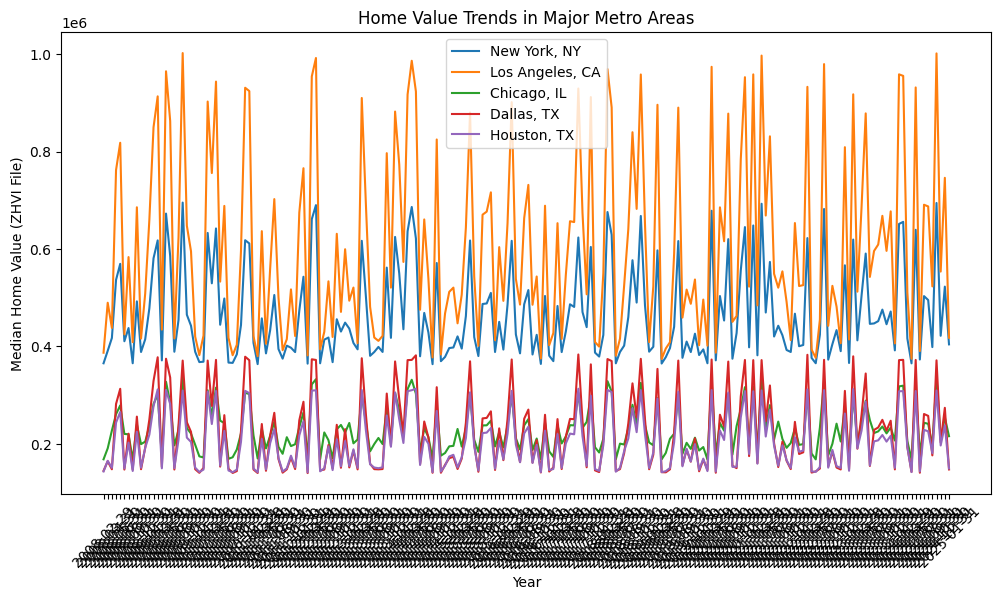

In [ ]:
import matplotlib.pyplot as plt

# Select a few major metro areas for visualization
metros = ["New York, NY", "Los Angeles, CA", "Chicago, IL", "Dallas, TX", "Houston, TX"]

# Filter data for selected metros
df_selected = df_merged[df_merged["RegionName"].isin(metros)]

# Convert date columns to numerical time series
dates = sorted(common_dates)

# Plot home values over time
plt.figure(figsize=(12, 6))
for metro in metros:
    metro_data = df_selected[df_selected["RegionName"] == metro].iloc[:, 3:len(common_dates) + 3].values.flatten()
    plt.plot(dates, metro_data, label=metro)

plt.xlabel("Year")
plt.ylabel("Median Home Value (ZHVI File)")
plt.title("Home Value Trends in Major Metro Areas")
plt.legend()
plt.xticks(rotation=45)
plt.show()

<ipython-input-10-e2f8dc181267>:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_market_melted, x="Date", y="ZHVI", estimator="mean", ci=None)


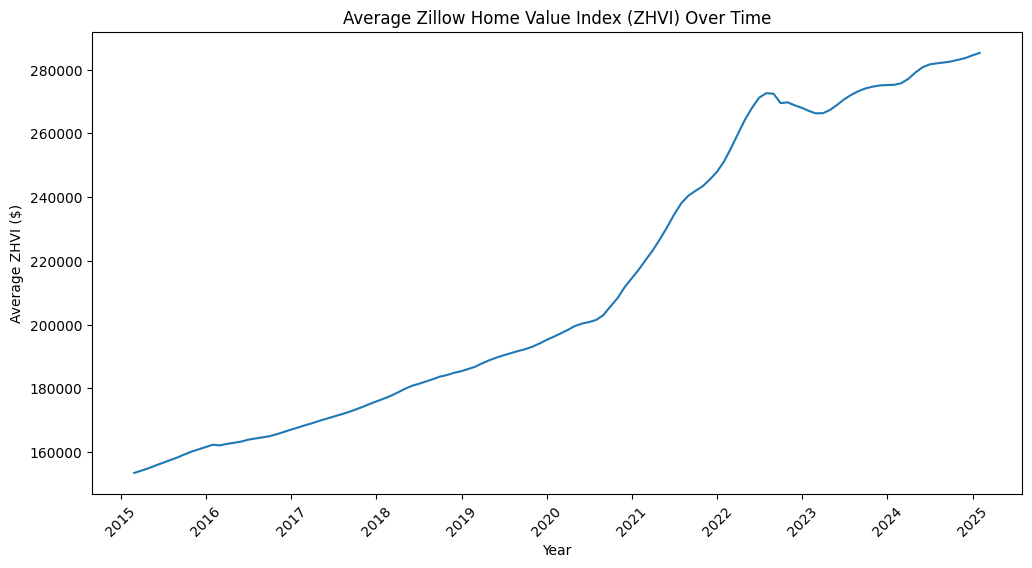

<ipython-input-10-e2f8dc181267>:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_sales_melted, x="Date", y="SalesCount", estimator="mean", ci=None)


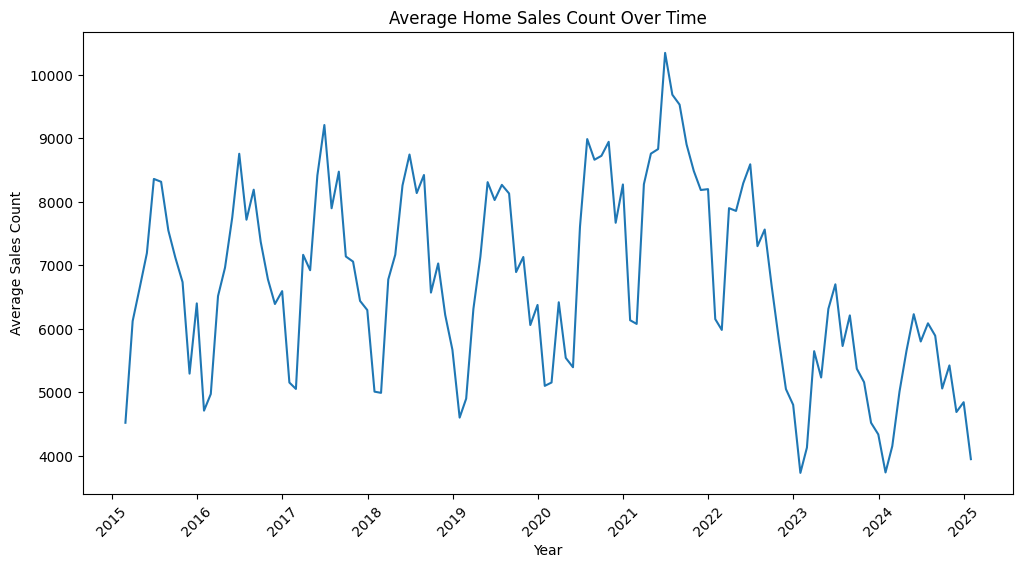

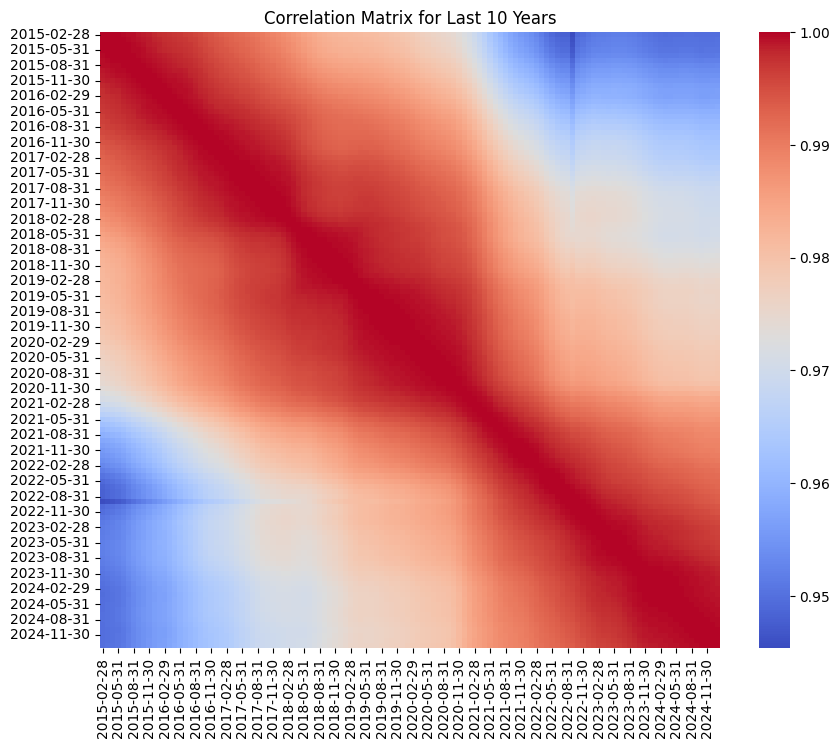

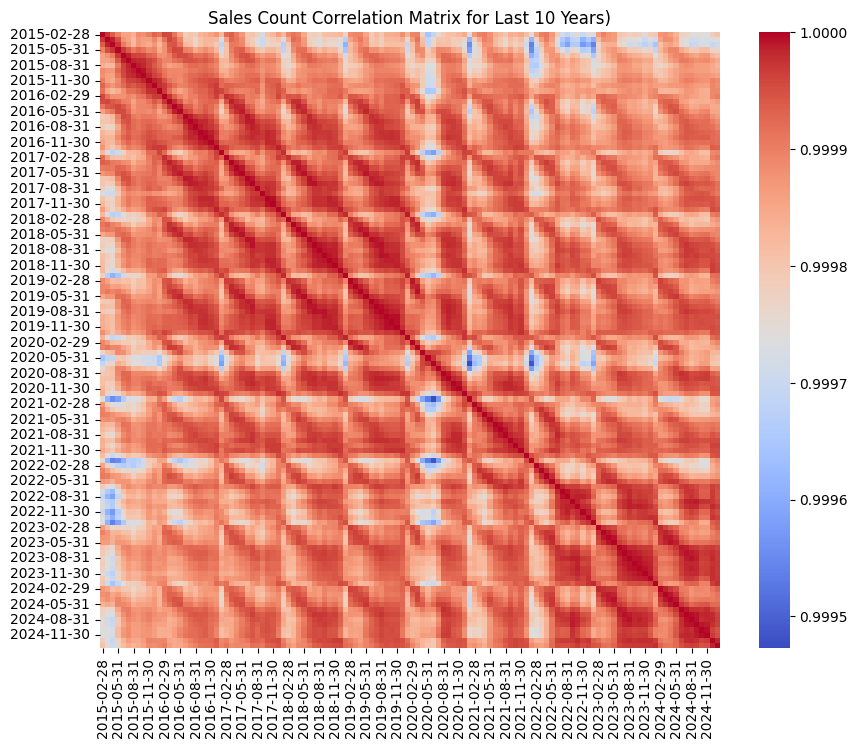

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select the most recent years for visualization (last 10 years)
years = [col for col in df_market.columns if col.startswith('20')][-120:]  # Last 120 months (10 years)

# Convert wide format to long format for visualization
df_market_melted = df_market.melt(id_vars=["RegionID", "RegionName", "StateName"],
                              value_vars=years,
                              var_name="Date",
                              value_name="ZHVI")

df_sales_melted = df_sales.melt(id_vars=["RegionID", "RegionName", "StateName"],
                                value_vars=years,
                                var_name="Date",
                                value_name="SalesCount")

# Convert Date column to datetime for proper plotting
df_market_melted["Date"] = pd.to_datetime(df_market_melted["Date"])
df_sales_melted["Date"] = pd.to_datetime(df_sales_melted["Date"])

# Plot average ZHVI trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_market_melted, x="Date", y="ZHVI", estimator="mean", ci=None)
plt.title("Average Zillow Home Value Index (ZHVI) Over Time")
plt.xlabel("Year")
plt.ylabel("Average ZHVI ($)")
plt.xticks(rotation=45)
plt.show()

# Plot average Sales Count trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_sales_melted, x="Date", y="SalesCount", estimator="mean", ci=None)
plt.title("Average Home Sales Count Over Time")
plt.xlabel("Year")
plt.ylabel("Average Sales Count")
plt.xticks(rotation=45)
plt.show()

# Correlation Matrices
# Convert the time-series columns to numeric for correlation
df_market_corr = df_market[years].corr()
df_sales_corr = df_sales[years].corr()

# Plot Correlation Heatmap for ZHVI
plt.figure(figsize=(10, 8))
sns.heatmap(df_market_corr, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix for Last 10 Years")
plt.show()

# Plot Correlation Heatmap for Sales Count
plt.figure(figsize=(10, 8))
sns.heatmap(df_sales_corr, cmap="coolwarm", annot=False)
plt.title("Sales Count Correlation Matrix for Last 10 Years)")
plt.show()

##**Pre-Analysis Plan**

Question: Can historical trends in home values and sales activity be used to predict median home values one year ahead in major U.S. metropolitan areas?

The learning type most suitable for these data plots is supervised learning/regression. Our target variable sales count is continous and can be analyzed best through supervised learning. Linear regression will be used as a beginning model. Then use LASSO regression to address multicollinearity when incorporating potential lagged monthly values. These models will exist to prevent overfitting when studying the predictive variables. To study these variables and their effects between each other more extensively we might also implement a Random Forest Regression model.

Sucess criteria will include using RMSE and MAE to quantify prediction accuracy on a test set. With the  time-series nature of this specific data, we will try to implement a time-aware train/test split, where the model is trained on earlier years and tested on more recent data, to better reflect real-world forecasting conditions and avoid data leakage. Visual comparisions on predicted versus actual values over will focus on larger cities (New York, Los Anageles, etc.) as it provides a greater range of data to work with and understand when analyzing when predictions may succeed or fail.

Some challenges that we anticipate in our analysis are addressing missing/inconsistent data and high dimensionality. For working with missing/inconsistent data, we will interpolate missing values and further analyze areas with significant gaps to see wheter they must be dropped. Since the nature of our data is time-series, high dimensionality might introduce greater noise. To address this, we might break our data up into seasional data and averages. If our models perform poorly it indicates to us that the factors we studied/focused on within our dataset do not play a role in driving home values. We would also be able to make conclusions about the impact of these variables given the time periods we study them in (short-term, monthly, etc.). It might highlight studying patterns over a longer period such as yearly might better mitigate noise and reveal more complex patterns.

Our next steps in handling our datasets will including converting monthly time serious to lag features, computing yearly changes in ZHVI and sales, add rolling averages to eliminate noise, and using clustering to group similar markets. Through this plan, we hope to present our results through regression metrics, model coeffictients, visual representations, and comparision plots.